<a href="https://colab.research.google.com/github/Ishita1609/Ishita-Singh/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - Phase 1
### Name: Ishita Singh
### Register Number: 23BDS0189
### Dataset: VerbAgg.csv

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")



1. Loading the Dataset


In [32]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/VerbAgg.csv"

df = pd.read_csv(url)

df.head()

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
0,1,20,M,S1WantCurse,no,1,curse,other,want,N
1,2,11,M,S1WantCurse,no,2,curse,other,want,N
2,3,17,F,S1WantCurse,perhaps,3,curse,other,want,Y
3,4,21,F,S1WantCurse,perhaps,4,curse,other,want,Y
4,5,17,F,S1WantCurse,perhaps,5,curse,other,want,Y


2. Basic Statistical Analysis

In [33]:
df.shape

(7584, 10)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7584 entries, 0 to 7583
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  7584 non-null   int64 
 1   Anger     7584 non-null   int64 
 2   Gender    7584 non-null   object
 3   item      7584 non-null   object
 4   resp      7584 non-null   object
 5   id        7584 non-null   int64 
 6   btype     7584 non-null   object
 7   situ      7584 non-null   object
 8   mode      7584 non-null   object
 9   r2        7584 non-null   object
dtypes: int64(3), object(7)
memory usage: 592.6+ KB


In [35]:
df.describe(include='all')

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
count,7584.000000,7584.000000,7584,7584,7584,7584.0000,7584,7584,7584,7584
unique,NaN,NaN,2,24,3,NaN,3,2,2,2
top,NaN,NaN,F,S1WantCurse,no,NaN,curse,other,want,N
freq,NaN,NaN,5832,316,3973,NaN,2528,3792,3792,3973
mean,3792.500000,20.003165,NaN,NaN,NaN,158.5000,NaN,NaN,NaN,NaN
std,2189.456554,4.841139,NaN,NaN,NaN,91.2269,NaN,NaN,NaN,NaN
min,1.000000,11.000000,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN
25%,1896.750000,17.000000,NaN,NaN,NaN,79.7500,NaN,NaN,NaN,NaN
50%,3792.500000,19.000000,NaN,NaN,NaN,158.5000,NaN,NaN,NaN,NaN
75%,5688.250000,23.000000,NaN,NaN,NaN,237.2500,NaN,NaN,NaN,NaN


In [36]:
df.columns

Index(['rownames', 'Anger', 'Gender', 'item', 'resp', 'id', 'btype', 'situ',
       'mode', 'r2'],
      dtype='object')

In [37]:
df.dtypes

,0
rownames,int64
Anger,int64
Gender,object
item,object
resp,object
id,int64
btype,object
situ,object
mode,object
r2,object


In [38]:
df.nunique()

,0
rownames,7584
Anger,26
Gender,2
item,24
resp,3
id,316
btype,3
situ,2
mode,2
r2,2


3. Handling missing data




In [39]:
df.isnull().sum()

,0
rownames,0
Anger,0
Gender,0
item,0
resp,0
id,0
btype,0
situ,0
mode,0
r2,0


In [40]:
if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found.")

No missing values found.


4. Data cleaning

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.drop_duplicates(inplace=True)

print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


5. Data Transformation

In [43]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

df.head()

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
0,1,20,1,3,0,1,0,0,1,0
1,2,11,1,3,0,2,0,0,1,0
2,3,17,0,3,1,3,0,0,1,1
3,4,21,0,3,1,4,0,0,1,1
4,5,17,0,3,1,5,0,0,1,1


In [44]:
scaler = StandardScaler()

numeric = df.select_dtypes(include=np.number).columns

df[numeric] = scaler.fit_transform(df[numeric])


6. Univariate analysis with a minimum of three visualizations

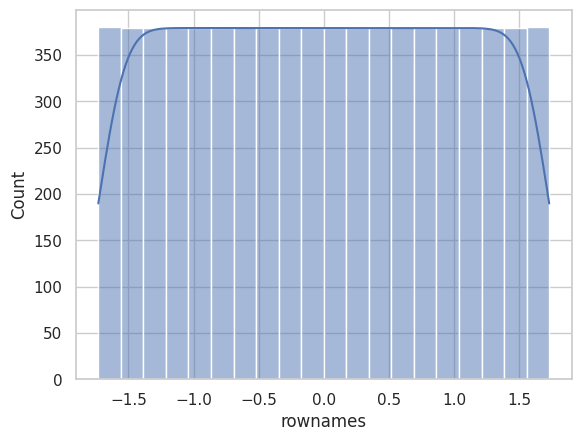

In [45]:
sns.histplot(df.iloc[:,0], kde=True)

plt.show()

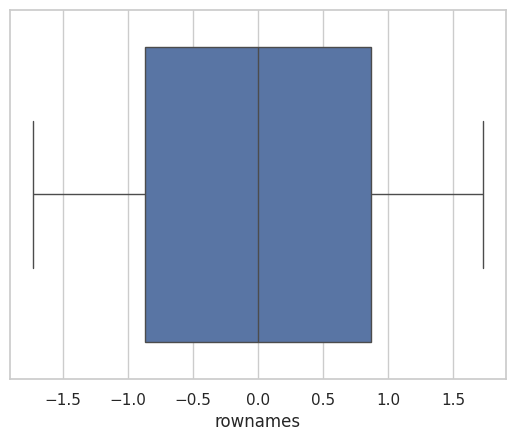

In [46]:
sns.boxplot(x=df.iloc[:,0])

plt.show()

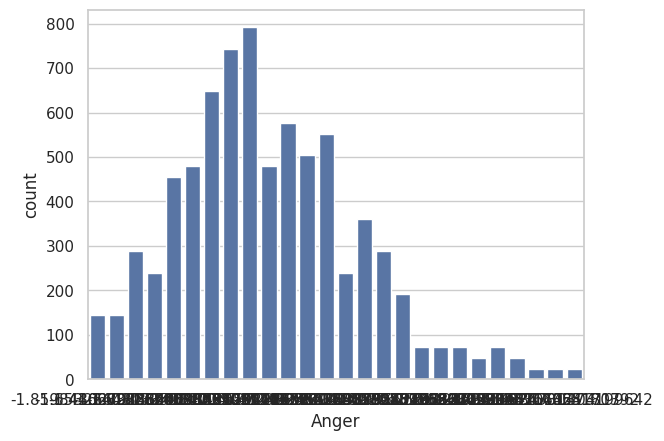

In [47]:
sns.countplot(x=df.iloc[:,1])

plt.show()

7. Bivariate analysis with a minimum of three visualizations



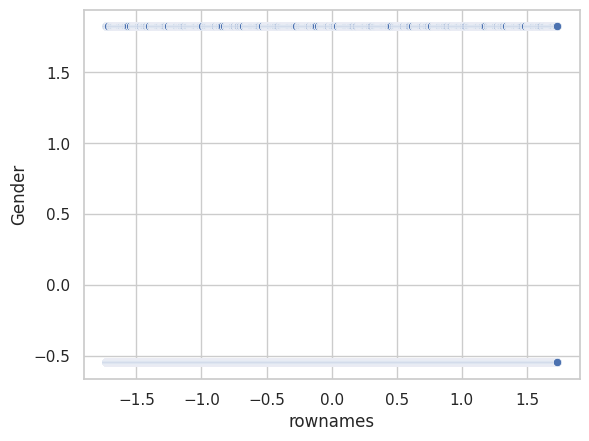

In [48]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,2])

plt.show()

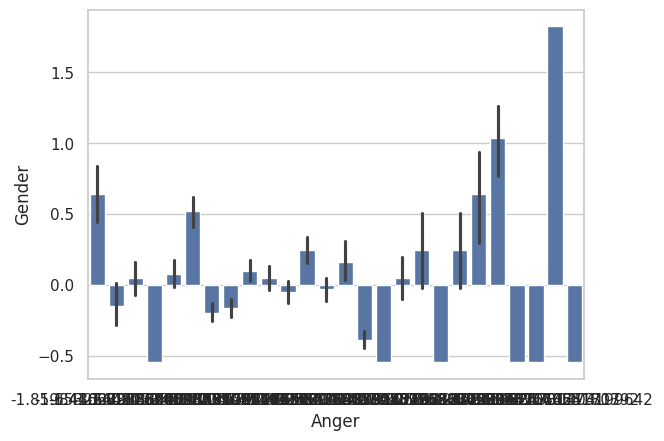

In [49]:
sns.barplot(x=df.iloc[:,1], y=df.iloc[:,2])

plt.show()

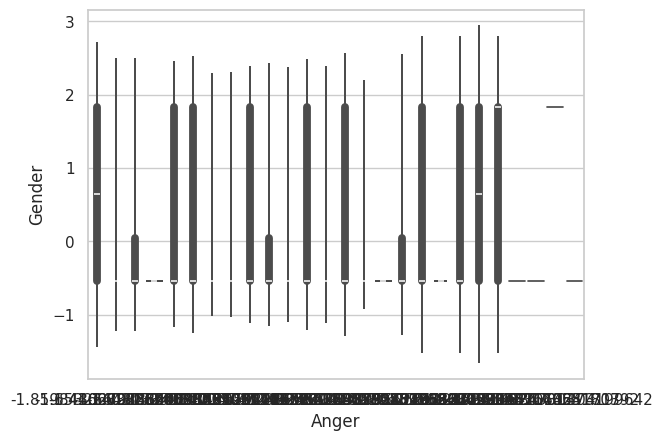

In [50]:
sns.violinplot(x=df.iloc[:,1], y=df.iloc[:,2])

plt.show()


8. Multivariate analysis with a minimum of three visualizations



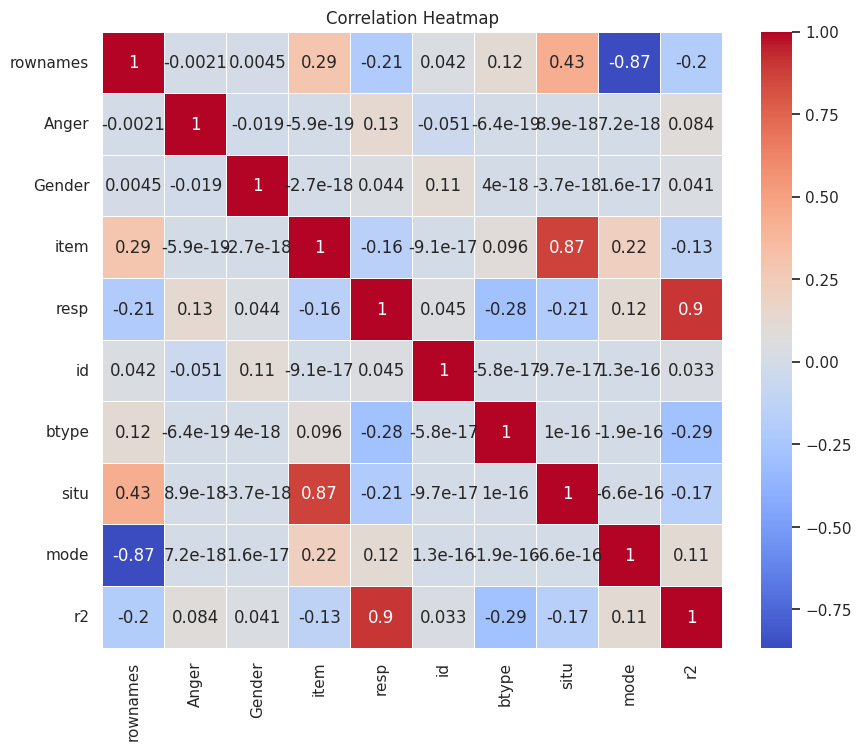

In [51]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

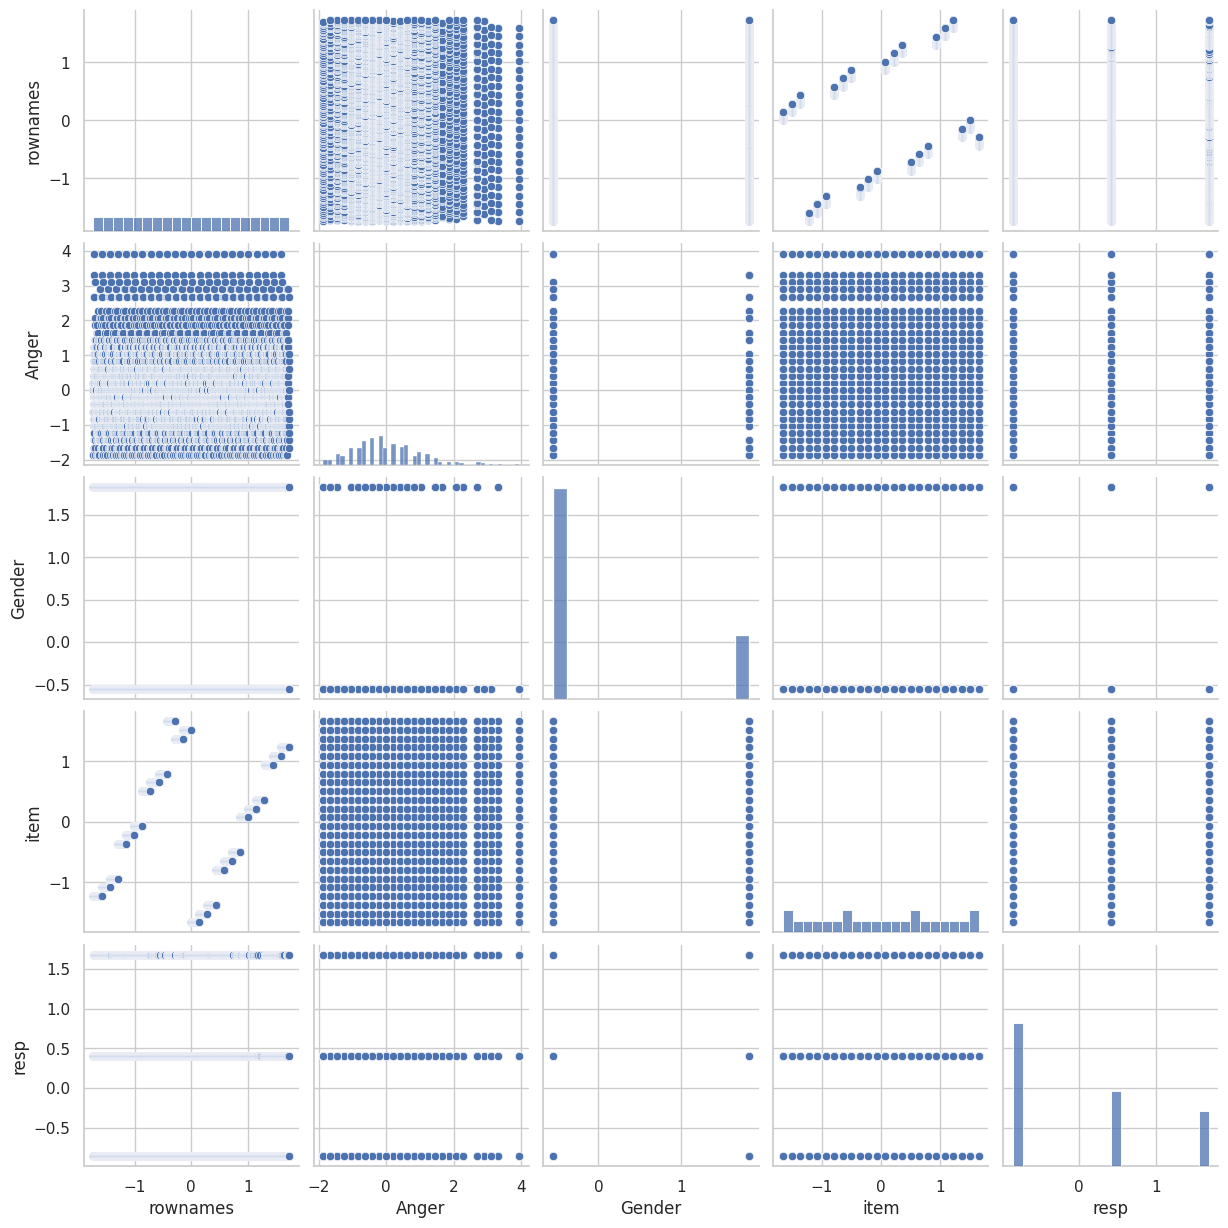

In [52]:
numeric_df = df.select_dtypes(include="number")

sns.pairplot(numeric_df.iloc[:, :5])

plt.show()

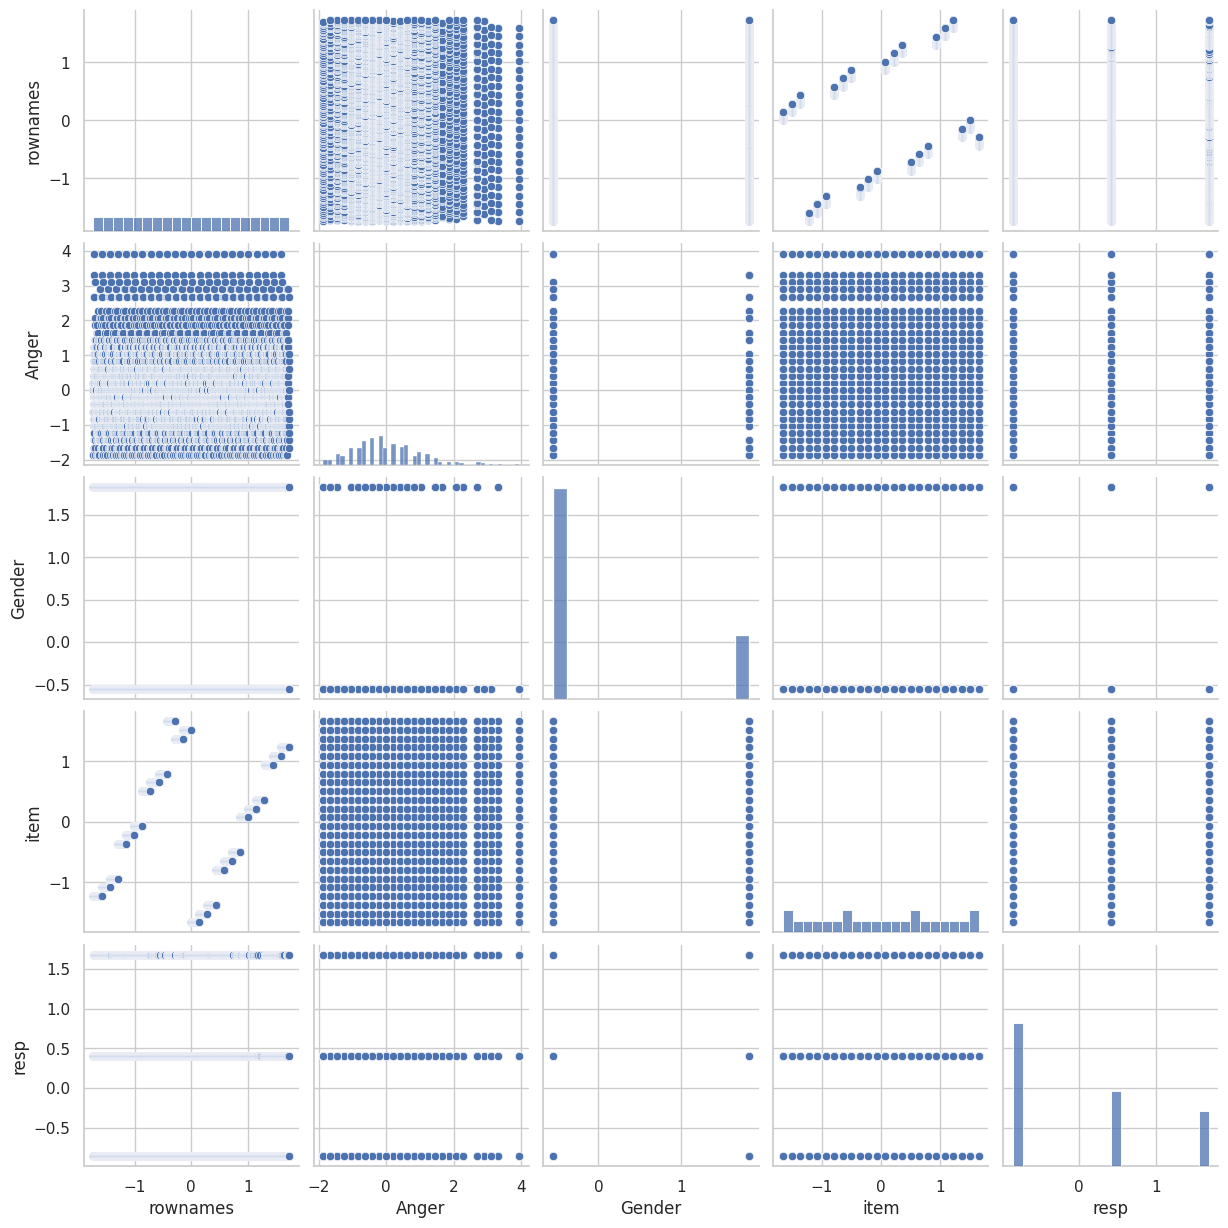

In [53]:
numeric_df = df.select_dtypes(include="number")

sns.pairplot(
    numeric_df.iloc[:, :5],
    diag_kind="hist"
)

plt.show()

Conclusion

- Successfully loaded the VerbAgg dataset.
- Performed statistical analysis to understand the dataset.
- Checked for missing values and duplicate records.
- Applied data cleaning and transformation techniques.
- Conducted univariate, bivariate and multivariate analyses.
- Generated multiple visualizations to understand the data distribution and relationships among variables.